In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from model_utils import get_model
from data_utils import get_train_dataset, get_tokenizer
from train_utils import train, save_model, make_dir, get_ident_name, get_data_ident_name, get_task_dir_name, get_lrs, add_lr, ce_loss
from test_utils import evaluation
from generate import force_args, task_choices

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

/home/jfcooper2/miniconda3/envs/hybrid/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
mixed = True

class Args:
    # layer1 = "SSM"
    layer1 = "GDN"
    # layer1 = "TF"
    # layer1 = None
    # layer2 = "SSM"
    # layer2 = "GDN"
    layer2 = "TF"
    # layer2 = None
    layer3 = None

    # model = "TF"
    model = None
    # num_layers = 2
    num_layers = None
    hidden_size = 24 # 24
    heads = 1
    state_dim = 16 # 1
    window = 20
    # window = 100
    nope = False

    train_task = "var-copy"
    # train_task = "needle"
    # train_task = "decode-recall"
    # train_task = "assoc-recall"
    # train_task = "assoc-recall-mk"
    num_numbers = 5
    # num_vocab = 8
    # num_vocab = 10
    # num_vocab = 50
    num_vocab = 26
    eval_p = None
    p = 0.2
    mixed = False

    sequence_length = 100
    min_train_length = 97
    max_train_length = 98
    min_eval_length = 97
    max_eval_length = 98
    num_examples = 1000
    num_eval_examples = 1000

    train_batch_size = 8
    eval_batch_size = 8
    eval_num_batches = 1
    pack_examples = False
    gradient_accumulation_steps = 1
    
    epochs = 10

    auto_lr = True
    force_do_lr = True # False
    test_generate = False
    save_results = False
    save_model = False

    progress_bar = False
    print = True

    run_number = 0

    def __init__(self):
        pass

args = Args()

In [4]:
# Check the user is specifying either model or layers
do_layers = args.layer1 and args.layer2
do_model = args.model and args.num_layers
if do_model and (args.layer1 or args.layer2):
    assert False, "Cannot specify both model and layers"
if do_layers and (args.model or args.num_layers):
    assert False, "Cannot specify both model and layers"
if not do_layers and not do_model:
    assert False, "Must specify either model or layers"


# Set the layers based on either the model or the specified layers
if do_model:
    if args.model in ['TF', 'SSM', 'GDN']:
        args.layers = [args.model] * args.num_layers
    elif args.model == 'hybrid':
        args.layers = ['SSM', 'TF'] * (args.num_layers // 2)
        if args.num_layers % 2 == 1:
            args.layers.append('SSM')
else:
    if args.layer3 is not None:
        args.layers = [args.layer1, args.layer2, args.layer3]
    else:
        args.layers = [args.layer1, args.layer2]

# Set the eval dataset to be the same as the train dataset if not specified
if args.eval_p is None:
    args.eval_p = args.p

# Force task specific arguments
force_args(args)

if not args.auto_lr and args.save_results and args.run_number >= 0 and not args.run_anyways:
    result_filename = 'results/' + get_task_dir_name(args) + '/%d.json' % args.run_number
    if os.path.exists(result_filename):
        exit(0)

args.data_name = get_data_ident_name(args)

if args.print:
    print(args)


## Get train dataset & tokenizer
tokenizer = get_tokenizer(args)
train_dataset = get_train_dataset(args, tokenizer) 

batch = next(iter(train_dataset))

if args.print:
    print("v"*100)
    print("EXAMPLE:", batch['input'][0])
    # print("STRUNG:", tokenizer.to_string(batch['input_ids'][0]))
    print("-"*100)
    print("TOKENIZED:", batch['input_ids'][0][batch['mask'][0]==1])
    print("^"*100)

if args.test_generate:
    i = batch['input'][0].index("#0")
    print(batch['input'][0][i])
    print(batch['input'][0][i+1])
    print(batch['output'][0][-1])
    exit(0)


## Find the best LR
if args.auto_lr:
    lrs = get_lrs(args)
    key = get_data_ident_name(args) + "_" + get_ident_name(args)
    if args.print:
        print(key)

    if key not in lrs.keys() or (args.force_do_lr and args.run_number == 0):
        losses = []
        for itr in range(2):
            for lr in np.geomspace(1e-4, 1e-0, num=9):
                model = get_model(args, tokenizer)
                args.lr = lr
                if args.print:
                    print("Testing LR:", lr)
                # _, final_loss = train(args, model, tokenizer, train_dataset)
                _, final_loss = train(args, model, tokenizer, train_dataset, one_epoch=True)
                if args.print:
                    print("Final loss:", final_loss)

                losses.append((final_loss, lr))
        losses.sort()
        best_lr = losses[0][1]
        add_lr(args, best_lr)

        args.lr = best_lr
    else:
        args.lr = lrs[key]

if args.save_results and args.run_number >= 0 and not args.run_anyways:
    result_filename = 'results/' + get_task_dir_name(args) + '/%d.json' % args.run_number
    if os.path.exists(result_filename):
        exit(0)

## Get model
model = get_model(args, tokenizer)

if args.print:
    print()
    print("v"*100)
    print(model)
    print(f"Number of parameters of the model: {count_parameters(model)}")
    print("^"*100)
    print()

vvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
EXAMPLE: ['V8', 'V13', 'V23', 'V9', '#7', 'V19', '#9', '#7', 'V11', 'V4', 'V18', 'V1', 'V23', '#5', 'V10', 'V21', 'V2', 'V7', '#6', 'V10', 'V9', 'V19', 'V15', 'V17', '#8', 'V7', 'V3', '#8', '#8', 'V19', 'V4', 'V12', '#5', 'V10', 'V1', 'V25', 'V10', '#6', 'V3', 'V11', 'V14', '#6', 'V4', 'V15', 'V17', 'V10', 'V5', 'V22', '#6', 'V2', 'V25', 'V5', 'V9', 'V2', 'V8', 'V0', 'V1', 'V2', 'V5', 'V16', 'V3', 'V18', '#7', '#6', 'V10', 'V25', 'V18', '#6', 'V22', 'V10', 'V6', 'V12', '#8', 'V16', 'V3', 'V19', 'V1', 'V21', '#5', '#7', 'V11', 'V25', 'V15', '#7', 'V16', '#6', 'V6', 'V4', 'V2', 'V13', 'V16', 'V15', 'V24', '#9', 'V13', 'V21', 'V3', 'V16', 'V24', 'V19']
----------------------------------------------------------------------------------------------------
TOKENIZED: tensor([28, 11,  4, 18,  1, 23, 26, 10, 21,  2,  7, 27, 10,  9, 19, 15, 17, 29,
         7,  3, 29, 29, 19,  4, 12, 26, 10,  1, 2

In [5]:
## train the model
accs, final_loss = train(args, model, tokenizer, train_dataset)

## save model
if args.save_model:
    save_model(args, model)

## evaluation of the model
if args.print:
    print("###EVALUATION")

model.eval()

str_acc_mean_list, str_acc_std_list, char_accuracy_list = evaluation(args, model, tokenizer)

if args.print:
    print(args)

    print("DONE")

    print("String")
    print(str_acc_mean_list)
    print("Char")
    print(char_accuracy_list)


if args.save_results and args.run_number >= 0:
    # assert False, "Decide what we want to actually save"
    results = {
        "train_accs": accs,
        "final_acc": char_accuracy_list,
        "final_loss": final_loss,
        "params": count_parameters(model),
        "args": vars(args)
    }

    make_dir(args)

    save_path = 'results/' + get_task_dir_name(args)
    with open(save_path + '/%d.json' % args.run_number, 'w') as f:
        json.dump(results, f)

0 1.0 0.8692505676420406
1 1.0 0.04014789807284251
2 1.0 0.0737277885649819
3 1.0 0.010344097855850123
4 1.0 0.020649947545141913
5 1.0 0.0049248302454361695
6 1.0 0.00508936865843134
7 1.0 0.0029526828338275663
8 1.0 0.0018675648088974412
9 1.0 0.0011003290809167084
###EVALUATION
DONE
String
[0.0]
Char
[1.0]


In [6]:
# model.hybrid.layers[0].mixer.x_proj
model

HybridForCausalLM(
  (hybrid): HybridModel(
    (embed_in): Embedding(34, 24)
    (emb_dropout): Dropout(p=0.1, inplace=False)
    (layers): ModuleList(
      (0): GatedLinearLayer(
        (layer): GatedDeltaNet(
          (q_proj): Linear(in_features=24, out_features=24, bias=False)
          (k_proj): Linear(in_features=24, out_features=24, bias=False)
          (v_proj): Linear(in_features=24, out_features=24, bias=False)
          (a_proj): Linear(in_features=24, out_features=1, bias=False)
          (b_proj): Linear(in_features=24, out_features=1, bias=False)
          (g_proj): Linear(in_features=24, out_features=24, bias=False)
          (o_norm): FusedRMSNormGated(24, eps=1e-05, activation=swish)
          (o_proj): Linear(in_features=24, out_features=24, bias=False)
        )
      )
      (1): GPTNeoXLayer(
        (input_layernorm): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
 

In [7]:
attention_mask = torch.ones((args.sequence_length, args.sequence_length))
attention_mask = (torch.triu(attention_mask, diagonal=0) - torch.triu(attention_mask, diagonal=args.window)).T.to('cuda')

device="cuda"

for step, batch in enumerate(train_dataset):
    x = batch['input_ids'].to(device)
    y = batch['output_ids'].to(device)
    loss_mask = batch['mask'].to(device)

    logits = model(x, attention_mask=attention_mask, return_dict=True, output_attentions=True, output_gdn_states=True)
    # logits = model(x, attention_mask=attention_mask, return_dict=True, output_attentions=True, output_gdn_states=False)
    # model(, output_attentions=True)

    loss = ce_loss(y, logits, loss_mask)
    # if (step+1) % args.num_log_steps == 0:
    #     avg_loss.append(0)
    #     count.append(0)
    loss = loss / args.gradient_accumulation_steps
    
    break

In [8]:
layer = 0
if logits["attentions"][layer] is not None:
    attn = logits["attentions"][layer][1,0].to("cpu").detach().numpy()
    plt.imshow(attn)

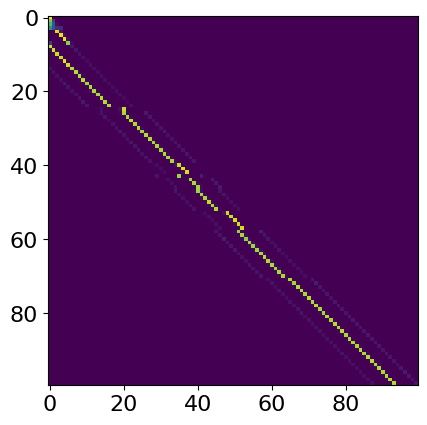

In [33]:
layer = 1
if logits["attentions"][layer] is not None:
    attn = logits["attentions"][layer][1,0].to("cpu").detach().numpy()
    plt.imshow(attn)

In [34]:
logits["gdn_states"][0]["state"].shape

torch.Size([8, 1, 100, 24, 24])

In [35]:
plt.rcParams.update({'font.size': 16, 'lines.linewidth': 2})

/tmp/ipykernel_61099/921924760.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


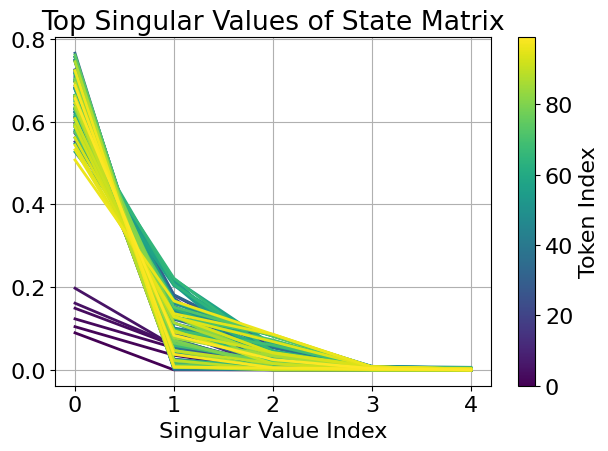

In [36]:
state = logits["gdn_states"][0]["state"]

s_array = []
for i in range(state.shape[2]):
    u, s, v = torch.linalg.svd(state[0,0,i])
    s_array.append(s.detach().cpu())

fig, ax = plt.subplots()

cmap = cm.get_cmap('viridis')
n = len(s_array)

for i, s in enumerate(s_array):
    color = cmap(i / (n - 1))
    ax.plot(s[:5].numpy(), color=color, lw=2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n - 1))
plt.colorbar(sm, ax=ax, label='Token Index')

plt.tight_layout()
plt.grid("minor")
plt.xlabel("Singular Value Index")
plt.title("Top Singular Values of State Matrix")
plt.tight_layout()

plt.savefig("results/interp/spectra.png", dpi=300)

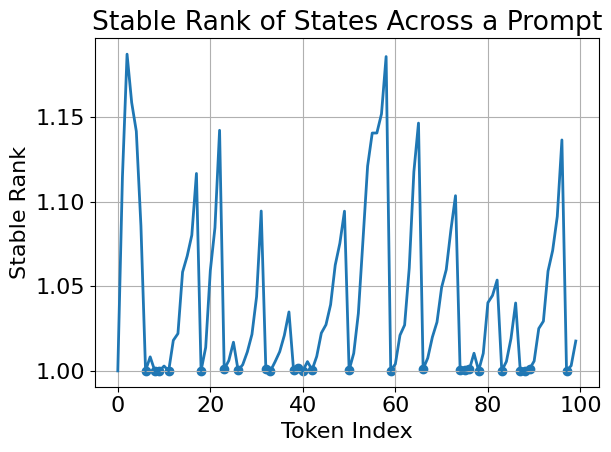

In [37]:
stable_ranks = [torch.sum(aa ** 2) / aa[0] ** 2 for aa in s_array]
plt.plot(stable_ranks)

xs = [i for i in range(100) if batch["input"][0][i][0] == '#']
ys = [stable_ranks[i] for i in xs]
plt.scatter(xs, ys)
plt.grid("minor")
plt.xlabel("Token Index")
plt.ylabel("Stable Rank")
plt.title("Stable Rank of States Across a Prompt")
plt.tight_layout()

plt.savefig("results/interp/srank.png", dpi=300)

Text(0.5, 1.0, '1-th Singular Value')

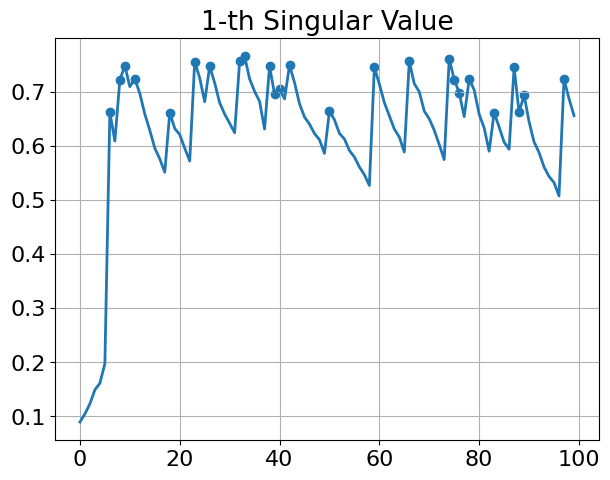

In [38]:
rank = 0

a = [aa[rank] for aa in s_array]
plt.plot(a)

xs = [i for i in range(100) if batch["input"][0][i][0] == '#']
ys = [a[i] for i in xs]
plt.scatter(xs, ys)
plt.grid("minor")
plt.tight_layout()
plt.title("%d-th Singular Value" % (rank + 1))

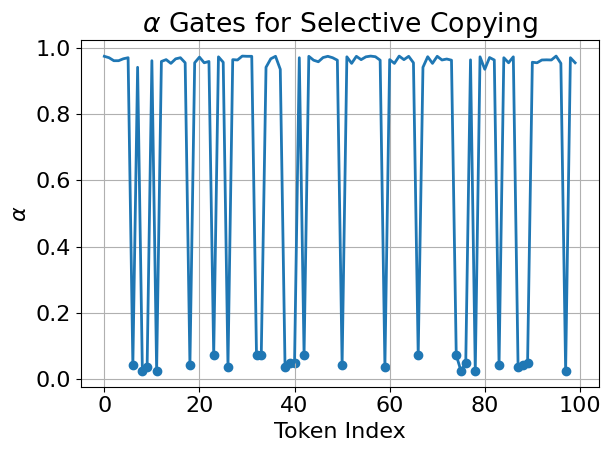

In [39]:
gates = logits["gdn_states"][0]["g"][0].cpu()
plt.plot(gates, lw=2)

xs = [i for i in range(100) if batch["input"][0][i][0] == '#']
ys = [gates[i] for i in xs]
plt.scatter(xs, ys)
plt.xlabel("Token Index")
plt.ylabel("$\\alpha$")
plt.grid("minor")
plt.title("$\\alpha$ Gates for Selective Copying")
plt.tight_layout()

plt.savefig("results/interp/gates.png", dpi=300)